# Introduccion a Redes Neuronales: Clasificacion Binaria

En este notebook aprenderemos a crear redes neuronales experimentando con diferentes configuraciones. Primero haremos, luego entenderemos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

# Funciones para visualizar resultados despues del entrenamiento
from utils import visualizar_entrenamiento, visualizar_multiclase

# Fijar semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.16.2


## Paso 1: Generar Datos

Creamos dos grupos de puntos en un plano 2D que queremos que la red aprenda a separar.

Datos de entrenamiento: 240 puntos
Datos de prueba: 60 puntos


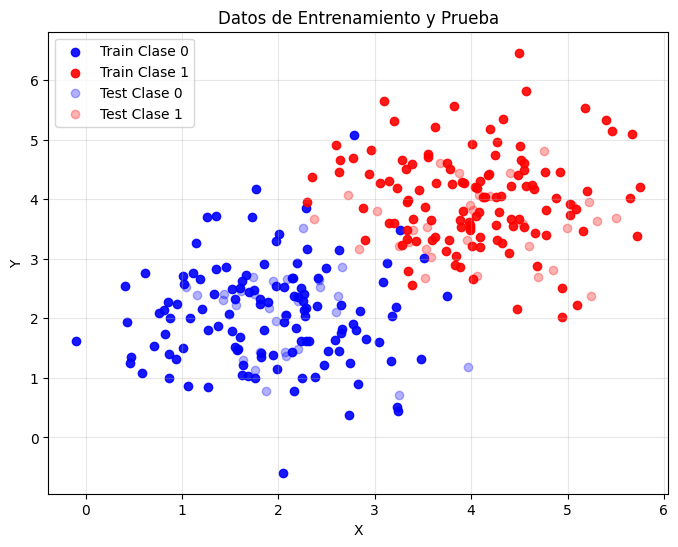

In [2]:
# Cantidad de puntos por clase
n_puntos = 150

# Clase 0 (azul): centrada en (2, 2)
clase_0_x = np.random.randn(n_puntos) * 0.8 + 2
clase_0_y = np.random.randn(n_puntos) * 0.8 + 2

# Clase 1 (rojo): centrada en (4, 4)
clase_1_x = np.random.randn(n_puntos) * 0.8 + 4
clase_1_y = np.random.randn(n_puntos) * 0.8 + 4

# Combinar todos los datos
X = np.column_stack([
    np.concatenate([clase_0_x, clase_1_x]),
    np.concatenate([clase_0_y, clase_1_y])
])
y = np.array([0] * n_puntos + [1] * n_puntos)

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} puntos")
print(f"Datos de prueba: {X_test.shape[0]} puntos")

# Visualizar datos
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='blue', label='Train Clase 0', alpha=0.9)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='red', label='Train Clase 1', alpha=0.9)
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c='blue', label='Test Clase 0', alpha=0.3)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c='red', label='Test Clase 1', alpha=0.3)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos de Entrenamiento y Prueba')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## modelo_1: El modelo mas simple posible (2 pesos)

Nuestro primer modelo tiene **exactamente 2 pesos**:
- Una sola neurona
- Sin bias
- Sin funcion de activacion

Esto nos permite visualizar **completamente** como funciona el gradiente descendente.

In [3]:
# modelo_1: 1 neurona, 2 pesos (w1, w2), sin bias
modelo_1 = keras.Sequential([
    keras.layers.Dense(1, input_shape=(2,), use_bias=False)
])

modelo_1.compile(
    optimizer=keras.optimizers.SGD(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Ver arquitectura
print("Arquitectura del modelo:")
print(f"\nTotal de pesos: {modelo_1.count_params()}")

# Entrenar
print("Entrenando modelo_1...")
historial_1 = modelo_1.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=0)

/Users/emiliosandoval/anaconda3/envs/ibero-nov-2025-05/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-24 00:29:36.069985: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-01-24 00:29:36.070126: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-24 00:29:36.070147: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-01-24 00:29:36.070489: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-24 00:29:36.070515: I tensorflow/core/common_runtime/pluggable_device/pluggabl

Arquitectura del modelo:

Total de pesos: 2
Entrenando modelo_1...


2026-01-24 00:29:36.741056: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



  RESULTADOS: modelo_1

Entrenamiento -> Loss: 7.9919, Accuracy: 50.42%
Validacion    -> Loss: 8.3277, Accuracy: 48.33%



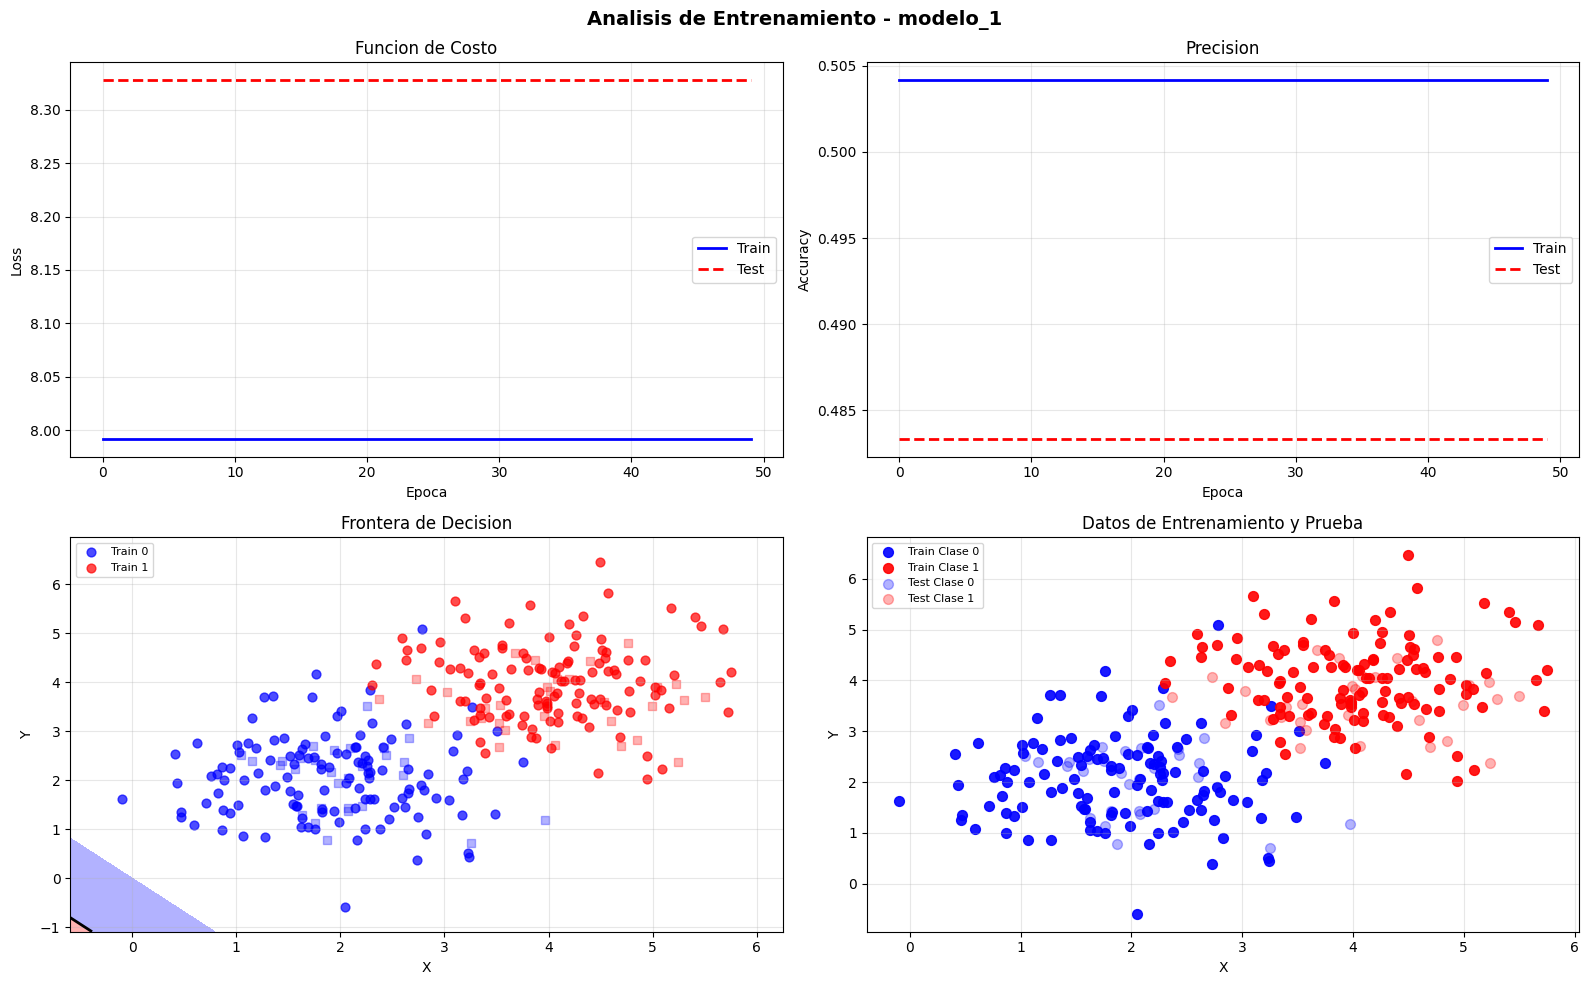

In [4]:
# Visualizar TODO: curvas, frontera, superficie de costo y gradiente descendente
visualizar_entrenamiento(modelo_1, historial_1, X_train, y_train, X_test, y_test, nombre='modelo_1')

## Por que solo podemos visualizar la superficie con 2 pesos?

La superficie de costo que vimos arriba muestra como cambia el **Loss** al variar los 2 pesos (w1, w2). Pudimos graficarla porque:

- **Eje X**: Peso w1
- **Eje Y**: Peso w2  
- **Eje Z**: Loss (el error)

Esto es una grafica **3D**, que es el maximo que podemos visualizar.

### Que pasa con modelos mas complejos?

Si tuvieramos un modelo con mas pesos, por ejemplo:

```python
keras.Sequential([
    keras.layers.Dense(5, input_shape=(2,)),  # 2×5 = 10 pesos + 5 biases
    keras.layers.Dense(1)                      # 5×1 = 5 pesos  + 1 bias
])                                             # Total: 21 parametros
```

Necesitariamos **22 dimensiones** para graficar la superficie (21 para los pesos + 1 para el Loss). Eso es imposible de visualizar.

### Lo importante

El algoritmo de **gradiente descendente funciona igual** sin importar cuantos pesos tenga el modelo:
1. Calcula el error (Loss)
2. Calcula la direccion de mayor descenso (gradiente)
3. Da un paso en esa direccion
4. Repite

La unica diferencia es que con 2 pesos podemos **ver** el valle, con 21 pesos el valle existe en 22 dimensiones pero no lo podemos dibujar.

## modelo_2: Agregamos mas capas (sin activacion)

Ahora creamos un modelo con mas neuronas y capas, pero todavia **sin funciones de activacion**.

In [5]:
# modelo_2: Mas capas, SIN funcion de activacion
modelo_2 = keras.Sequential([
    keras.layers.Dense(8, input_shape=(2,)),   # Capa oculta 1: 8 neuronas
    keras.layers.Dense(4),                      # Capa oculta 2: 4 neuronas
    keras.layers.Dense(1)                       # Capa de salida: 1 neurona
])

modelo_2.compile(
    optimizer=keras.optimizers.SGD(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\nTotal de pesos: {modelo_2.count_params()}")

# Entrenar modelo_2
print("Entrenando modelo_2...")
historial_2 = modelo_2.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)


Total de pesos: 65
Entrenando modelo_2...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.4833 - loss: 6.4670 - val_accuracy: 0.5833 - val_loss: 5.2709
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5708 - loss: 4.3260 - val_accuracy: 0.5000 - val_loss: 3.8046
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5417 - loss: 5.3453 - val_accuracy: 0.5833 - val_loss: 2.4601
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5417 - loss: 6.7975 - val_accuracy: 0.4833 - val_loss: 8.3277
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5042 - loss: 7.9925 - val_accuracy: 0.4833 - val_loss: 8.3277
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5042 - loss: 7.9921 - val_accuracy: 0.4833 - val_loss: 8.3277
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5042 - loss: 7.9920 - val_accuracy: 0.4833 - val_loss: 8.3277
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5042 - loss: 7.9920


  RESULTADOS: modelo_2

Entrenamiento -> Loss: 7.9919, Accuracy: 50.42%
Validacion    -> Loss: 8.3277, Accuracy: 48.33%



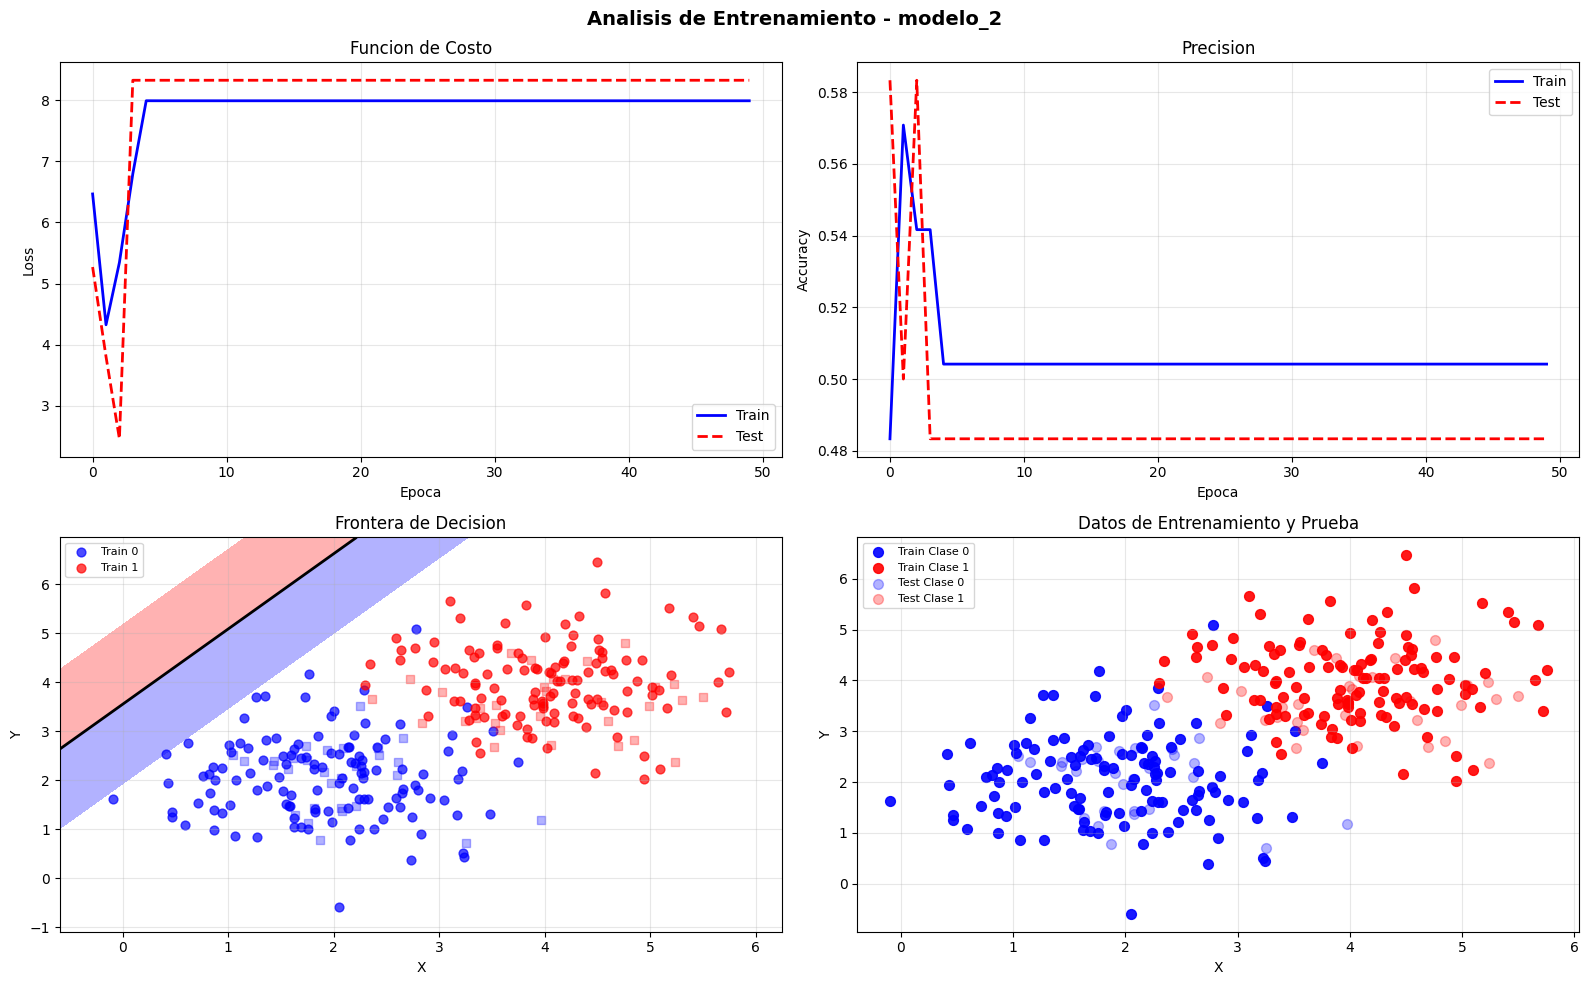

In [6]:
# Visualizar resultados
visualizar_entrenamiento(modelo_2, historial_2, X_train, y_train, X_test, y_test, nombre='modelo_2')

## modelo_3: Funciones de activacion

Los modelos anteriores sin activacion son esencialmente **lineales** (no importa cuantas capas tengan). Ahora agregamos:
- **ReLU** en capas ocultas: permite aprender patrones no lineales
- **Sigmoid** en la salida: convierte el resultado a probabilidad (0 a 1)

In [7]:
# modelo_3: Con funciones de activacion
modelo_3 = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(2,)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

modelo_3.compile(
    optimizer=keras.optimizers.SGD(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

historial_3 = modelo_3.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.4667 - loss: 1.3219 - val_accuracy: 0.4667 - val_loss: 0.7480
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 0.7070 - val_accuracy: 0.5167 - val_loss: 0.7035
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5500 - loss: 0.6898 - val_accuracy: 0.5500 - val_loss: 0.6904
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5500 - loss: 0.6781 - val_accuracy: 0.5500 - val_loss: 0.6790
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5458 - loss: 0.6671 - val_accuracy: 0.5500 - val_loss: 0.6684
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5458 - loss: 0.6568 - val_accuracy: 0.5667 - val_loss: 0.6584
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5458 - loss: 0.6470 - val_accuracy: 0.5667 - val_loss: 0.6490
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5583 - loss: 0.6378 - val_accuracy: 0.5667 - val_loss: 0.6401



  RESULTADOS: modelo_3

Entrenamiento -> Loss: 0.4047, Accuracy: 88.75%
Validacion    -> Loss: 0.4184, Accuracy: 86.67%



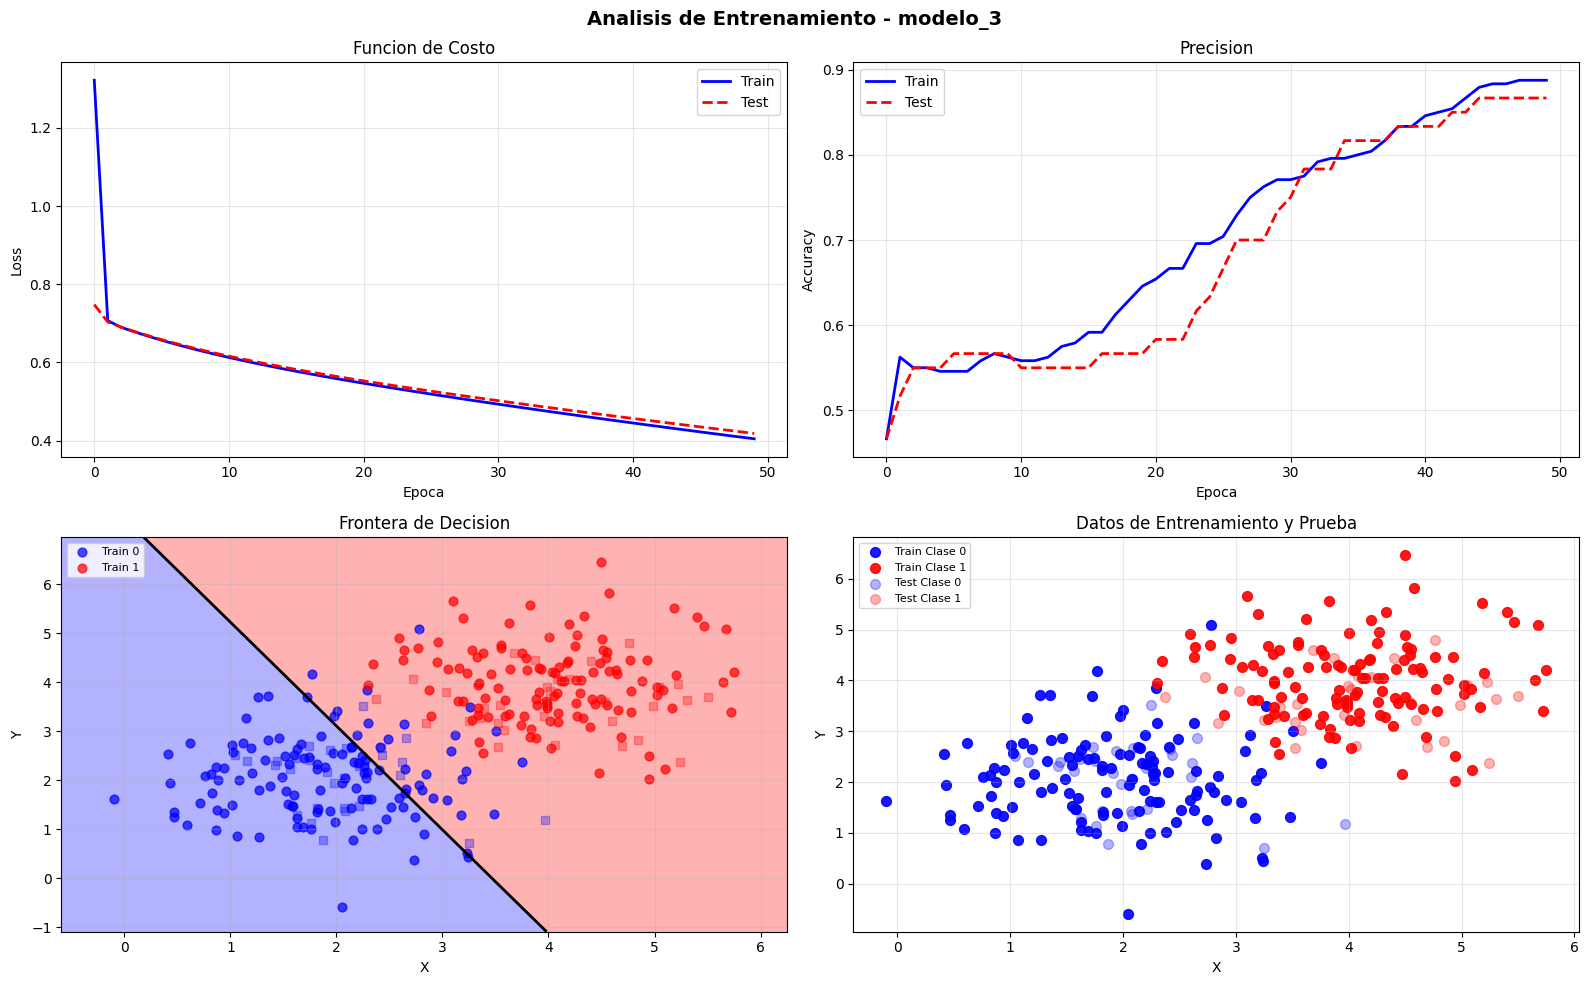

In [8]:
visualizar_entrenamiento(modelo_3, historial_3, X_train, y_train, X_test, y_test, nombre='modelo_3')

## modelo_4: Learning rate mas alto

Mismo modelo que modelo_3, pero con un learning rate mayor para ver como afecta el entrenamiento.

In [9]:
# modelo_4: Igual que modelo_3 pero con learning rate alto
modelo_4 = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(2,)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

modelo_4.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

historial_4 = modelo_4.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5417 - loss: 0.7787 - val_accuracy: 0.5167 - val_loss: 0.6189
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5958 - loss: 0.6039 - val_accuracy: 0.5167 - val_loss: 0.6045
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6333 - loss: 0.5887 - val_accuracy: 0.5333 - val_loss: 0.5909
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6625 - loss: 0.5744 - val_accuracy: 0.5500 - val_loss: 0.5780
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6792 - loss: 0.5606 - val_accuracy: 0.5500 - val_loss: 0.5657
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6917 - loss: 0.5475 - val_accuracy: 0.5500 - val_loss: 0.5539
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7083 - loss: 0.5350 - val_accuracy: 0.5500 - val_loss: 0.5425
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7292 - loss: 0.5230 - val_accuracy: 0.5833 - val_loss: 0.5317



  RESULTADOS: modelo_4

Entrenamiento -> Loss: 0.2855, Accuracy: 95.42%
Validacion    -> Loss: 0.3033, Accuracy: 95.00%



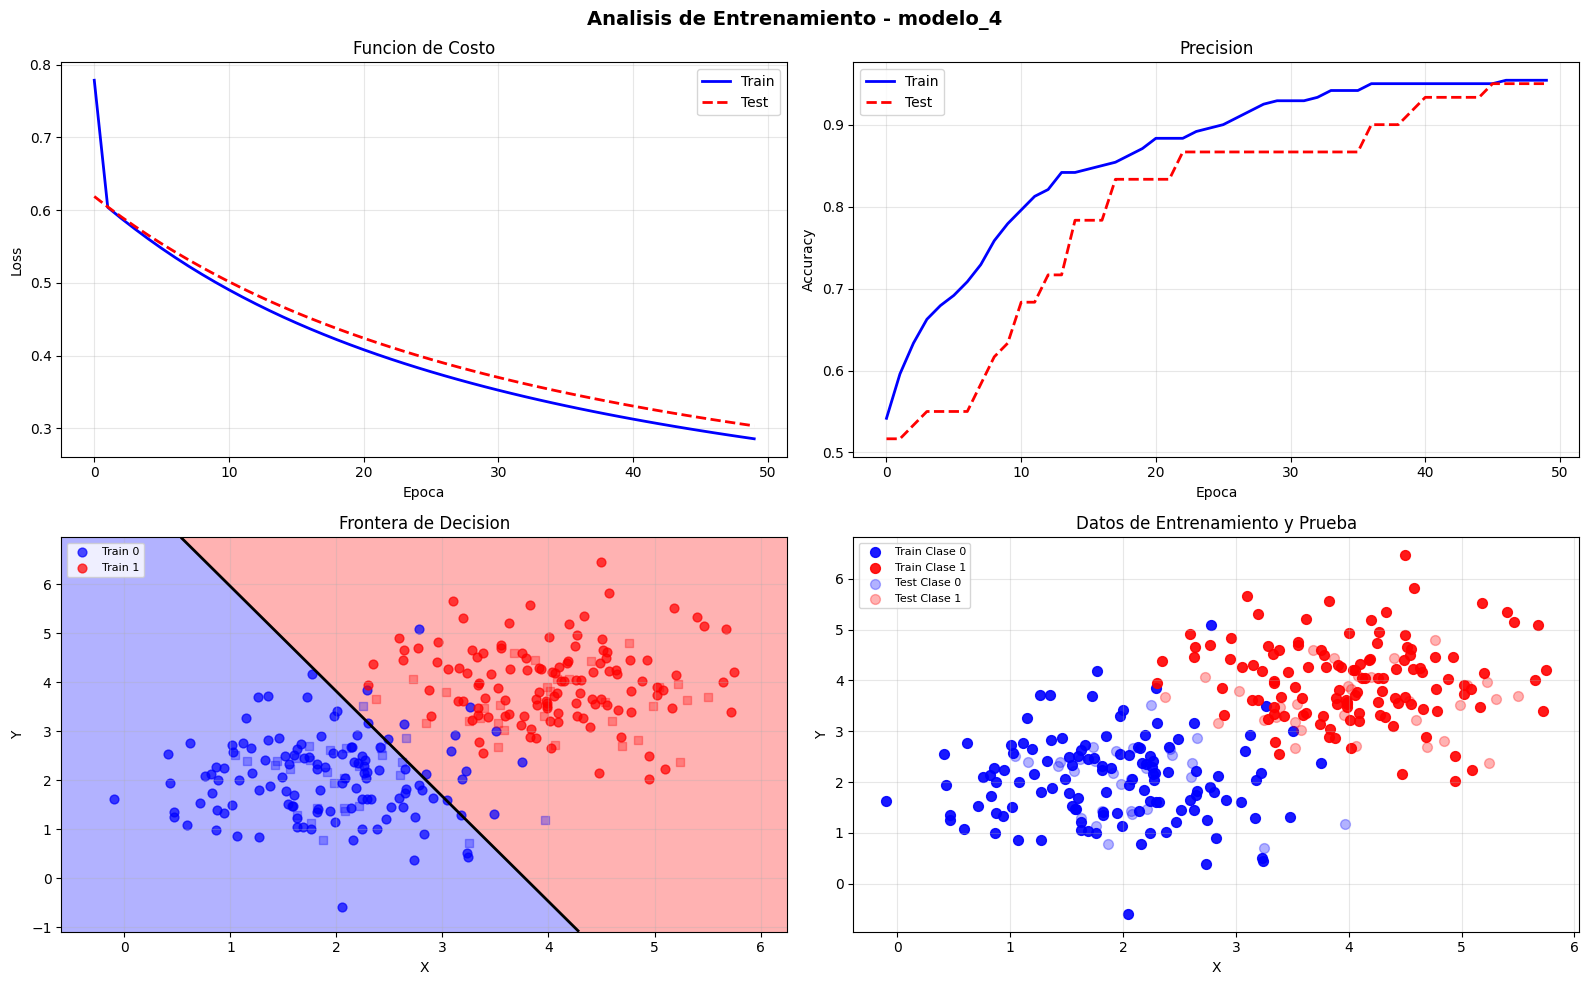

In [10]:
visualizar_entrenamiento(modelo_4, historial_4, X_train, y_train, X_test, y_test, nombre='modelo_4')

## modelo_5: Activacion tanh

Usamos **tanh** (tangente hiperbolica) en las capas ocultas. A diferencia de ReLU (0 a infinito), tanh produce valores entre -1 y 1, lo que puede ayudar en ciertos problemas.

In [11]:
# modelo_5: Con activacion tanh y mas neuronas
modelo_5 = keras.Sequential([
    keras.layers.Dense(16, activation='tanh', input_shape=(2,)),
    keras.layers.Dense(8, activation='tanh'),
    keras.layers.Dense(4, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')
])

modelo_5.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

historial_5 = modelo_5.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.3083 - loss: 0.7778 - val_accuracy: 0.5167 - val_loss: 0.6912
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6917 - loss: 0.6667 - val_accuracy: 0.5333 - val_loss: 0.6403
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8375 - loss: 0.6049 - val_accuracy: 0.6000 - val_loss: 0.5964
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8958 - loss: 0.5426 - val_accuracy: 0.7333 - val_loss: 0.5472
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9083 - loss: 0.4735 - val_accuracy: 0.8167 - val_loss: 0.4886
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9208 - loss: 0.4166 - val_accuracy: 0.9167 - val_loss: 0.3873
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8500 - loss: 0.4046 - val_accuracy: 0.9667 - val_loss: 0.3218
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8375 - loss: 0.3907 - val_accuracy: 0.9667 - val_loss: 0.2854



  RESULTADOS: modelo_5

Entrenamiento -> Loss: 0.0981, Accuracy: 95.83%
Validacion    -> Loss: 0.0711, Accuracy: 96.67%



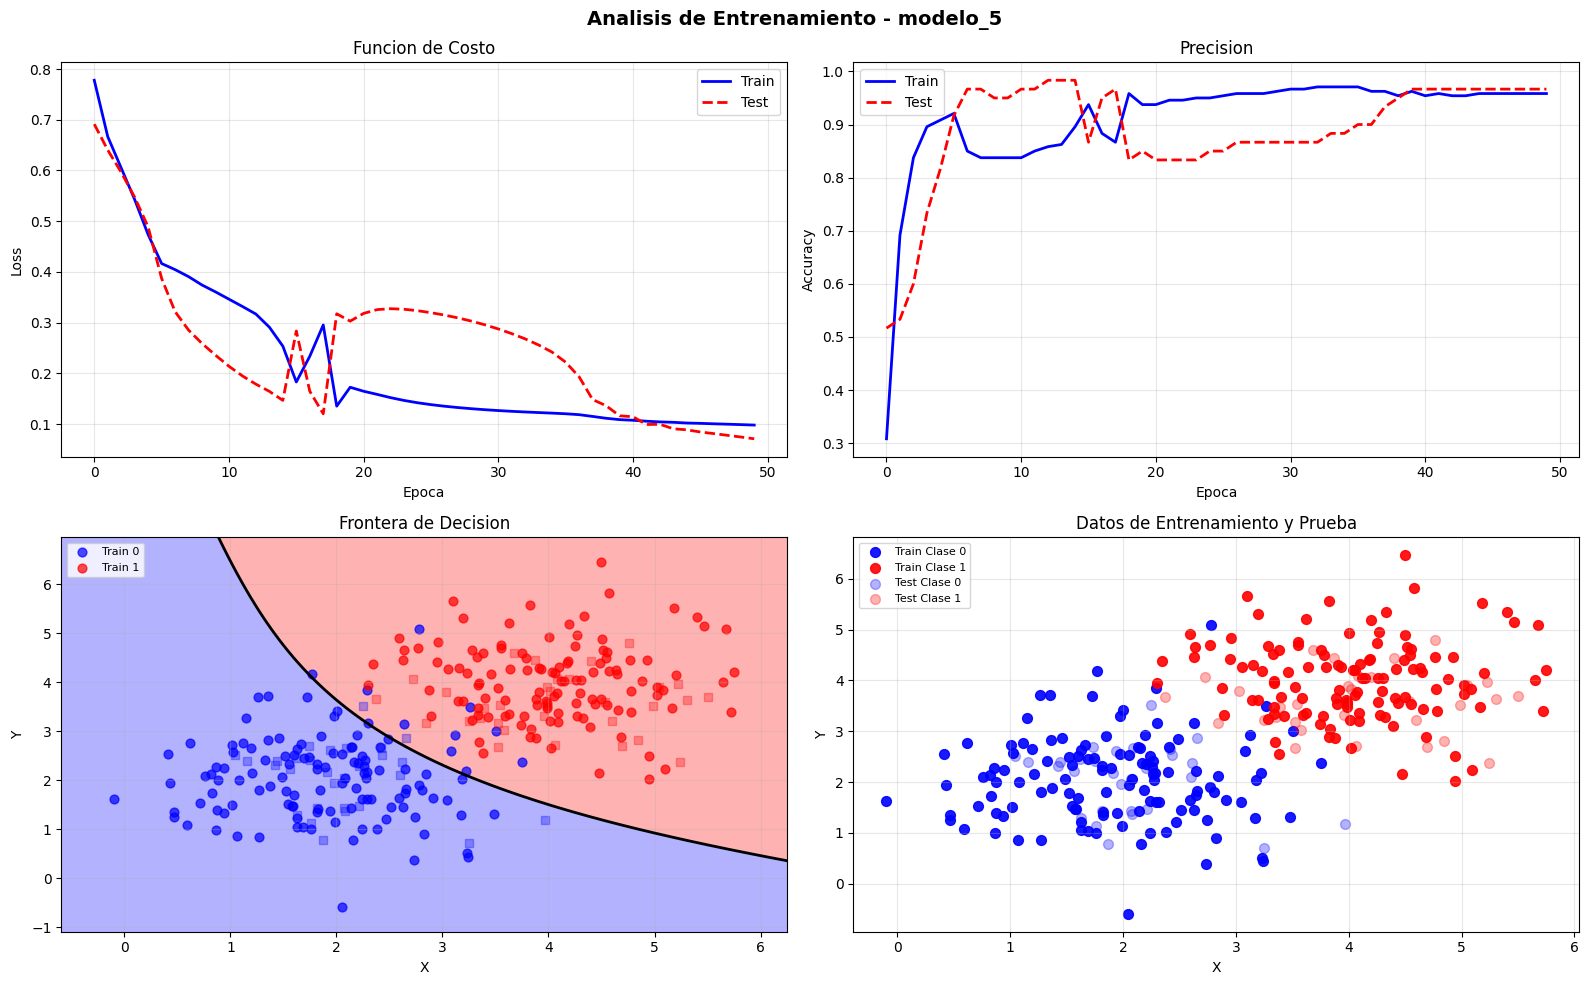

In [12]:
visualizar_entrenamiento(modelo_5, historial_5, X_train, y_train, X_test, y_test, nombre='modelo_5')

## modelo_6: Red mas profunda con Adam

### SGD vs Adam

**SGD (Stochastic Gradient Descent)**:
- Usa un learning rate fijo para todos los pesos
- Puede oscilar mucho si el learning rate es muy alto
- Puede quedarse atascado si es muy bajo

**Adam (Adaptive Moment Estimation)**:
- Adapta el learning rate para cada peso individualmente
- Combina las ventajas de dos algoritmos: Momentum y RMSprop
- Mas estable y generalmente converge mas rapido
- Es el optimizador mas usado en la practica

Cambios en este modelo:
- Optimizador **Adam**
- Red mas profunda (5 capas)
- Mas epochs (100)

In [13]:
# modelo_6: Red profunda con optimizador Adam
modelo_6 = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(2,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

modelo_6.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

historial_6 = modelo_6.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5042 - loss: 1.2029 - val_accuracy: 0.4833 - val_loss: 1.0697
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5042 - loss: 1.0127 - val_accuracy: 0.4833 - val_loss: 0.9181
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5042 - loss: 0.8909 - val_accuracy: 0.4833 - val_loss: 0.8427
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5042 - loss: 0.8294 - val_accuracy: 0.4833 - val_loss: 0.7974
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.7945 - val_accuracy: 0.4833 - val_loss: 0.7739
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.7745 - val_accuracy: 0.4833 - val_loss: 0.7566
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4917 - loss: 0.7588 - val_accuracy: 0.4500 - val_loss: 0.7421
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4750 - loss: 0.7469 - val_accuracy: 0.4333 - val_loss


  RESULTADOS: modelo_6

Entrenamiento -> Loss: 0.0770, Accuracy: 97.08%
Validacion    -> Loss: 0.0738, Accuracy: 96.67%



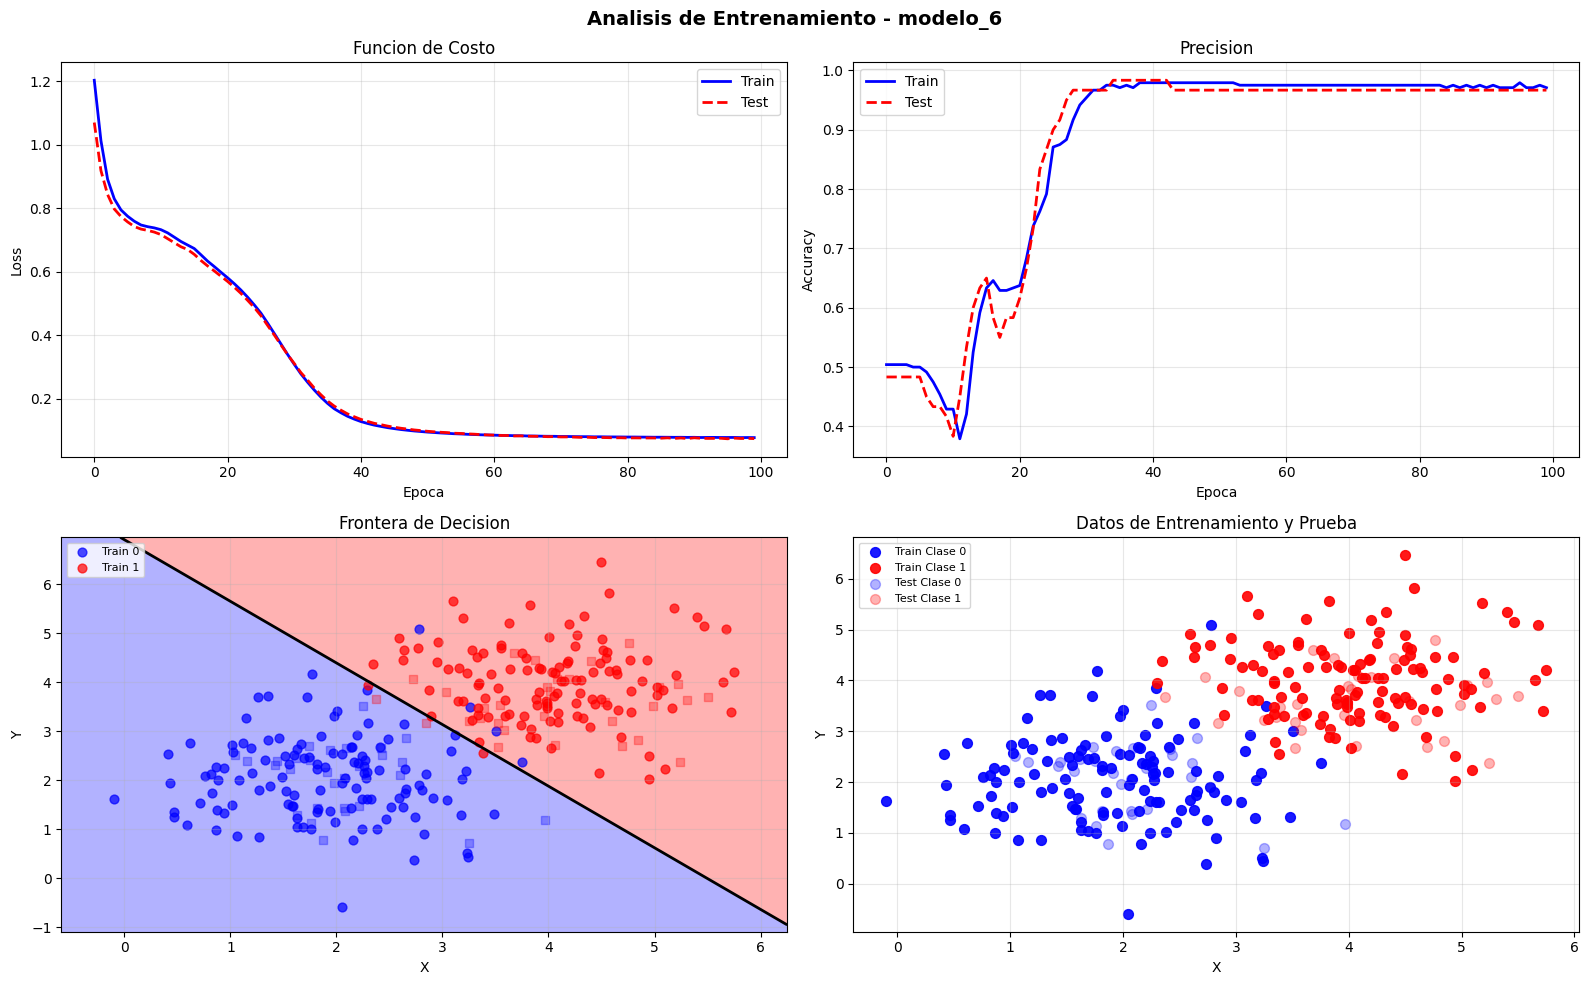

In [14]:
visualizar_entrenamiento(modelo_6, historial_6, X_train, y_train, X_test, y_test, nombre='modelo_6')

## Comparacion de Modelos

Veamos el rendimiento final de cada modelo:

In [15]:
import pandas as pd

modelos = {
    'modelo_1': (modelo_1, historial_1),
    'modelo_2': (modelo_2, historial_2),
    'modelo_3': (modelo_3, historial_3),
    'modelo_4': (modelo_4, historial_4),
    'modelo_5': (modelo_5, historial_5),
    'modelo_6': (modelo_6, historial_6),
}

resultados = []
for nombre, (modelo, historial) in modelos.items():
    loss_final = historial.history['loss'][-1]
    val_loss_final = historial.history['val_loss'][-1]
    acc_final = historial.history['accuracy'][-1]
    val_acc_final = historial.history['val_accuracy'][-1]
    n_params = modelo.count_params()
    
    resultados.append({
        'Modelo': nombre,
        'Parametros': n_params,
        'Loss (train)': round(loss_final, 4),
        'Loss (test)': round(val_loss_final, 4),
        'Accuracy (train)': round(acc_final, 4),
        'Accuracy (test)': round(val_acc_final, 4),
    })

df = pd.DataFrame(resultados)
df

,Modelo,Parametros,Loss (train),Loss (test),Accuracy (train),Accuracy (test)
0,modelo_1,2,7.9919,8.3277,0.5042,0.4833
1,modelo_2,65,7.9919,8.3277,0.5042,0.4833
2,modelo_3,65,0.4047,0.4184,0.8875,0.8667
3,modelo_4,65,0.2855,0.3033,0.9542,0.9500
4,modelo_5,225,0.0981,0.0711,0.9583,0.9667
5,modelo_6,801,0.0770,0.0738,0.9708,0.9667


## Guardar modelo_5

Exportamos el modelo para usarlo en otras aplicaciones (como n8n):

In [16]:
# Guardar en formato .h5 (compatible con la mayoria de herramientas)
modelo_5.save('modelo_5.h5')
print("Modelo guardado como: modelo_5.h5")

# Tambien guardamos en formato Keras nativo
modelo_5.save('modelo_5.keras')
print("Modelo guardado como: modelo_5.keras")

Modelo guardado como: modelo_5.h5
Modelo guardado como: modelo_5.keras


## Caso 2: Datos en Espiral

Ahora creamos un problema mucho mas dificil: dos clases entrelazadas en forma de espiral. Una red lineal no puede resolver esto.

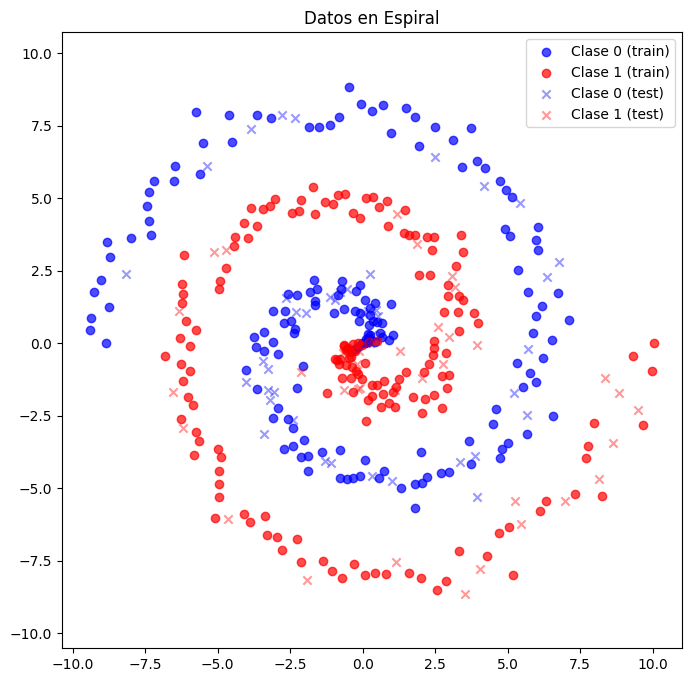

Train: 320 puntos | Test: 80 puntos


In [17]:
# Generar datos en espiral
np.random.seed(42)
tf.random.set_seed(42)

n_puntos = 200  # puntos por clase
ruido = 0.5

# Espiral clase 0
theta_0 = np.linspace(0, 3 * np.pi, n_puntos)
r_0 = theta_0 + np.random.randn(n_puntos) * ruido
x0 = r_0 * np.cos(theta_0)
y0 = r_0 * np.sin(theta_0)

# Espiral clase 1 (rotada 180 grados)
theta_1 = np.linspace(0, 3 * np.pi, n_puntos)
r_1 = theta_1 + np.random.randn(n_puntos) * ruido
x1 = r_1 * np.cos(theta_1 + np.pi)
y1 = r_1 * np.sin(theta_1 + np.pi)

# Combinar datos
X_espiral = np.vstack([np.column_stack([x0, y0]), np.column_stack([x1, y1])])
y_espiral = np.array([0] * n_puntos + [1] * n_puntos)

# Dividir en train/test
X_train_esp, X_test_esp, y_train_esp, y_test_esp = train_test_split(
    X_espiral, y_espiral, test_size=0.2, random_state=42
)

# Visualizar
plt.figure(figsize=(8, 8))
plt.scatter(X_train_esp[y_train_esp == 0, 0], X_train_esp[y_train_esp == 0, 1], c='blue', label='Clase 0 (train)', alpha=0.7)
plt.scatter(X_train_esp[y_train_esp == 1, 0], X_train_esp[y_train_esp == 1, 1], c='red', label='Clase 1 (train)', alpha=0.7)
plt.scatter(X_test_esp[y_test_esp == 0, 0], X_test_esp[y_test_esp == 0, 1], c='blue', marker='x', label='Clase 0 (test)', alpha=0.4)
plt.scatter(X_test_esp[y_test_esp == 1, 0], X_test_esp[y_test_esp == 1, 1], c='red', marker='x', label='Clase 1 (test)', alpha=0.4)
plt.title('Datos en Espiral')
plt.legend()
plt.axis('equal')
plt.show()

print(f"Train: {len(X_train_esp)} puntos | Test: {len(X_test_esp)} puntos")

## modelo_espiral_1: Red simple (probablemente falle)

Probemos primero con una red similar a modelo_3:

In [18]:
modelo_esp_1 = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(2,)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

modelo_esp_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

historial_esp_1 = modelo_esp_1.fit(X_train_esp, y_train_esp, epochs=100, validation_data=(X_test_esp, y_test_esp), verbose=1)

Epoch 1/100


/Users/emiliosandoval/anaconda3/envs/ibero-nov-2025-05/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3812 - loss: 1.6294 - val_accuracy: 0.3875 - val_loss: 1.4105
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3781 - loss: 1.4899 - val_accuracy: 0.4000 - val_loss: 1.2926
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3844 - loss: 1.3576 - val_accuracy: 0.3875 - val_loss: 1.1812
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3938 - loss: 1.2331 - val_accuracy: 0.3875 - val_loss: 1.0775
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4000 - loss: 1.1179 - val_accuracy: 0.3875 - val_loss: 0.9831
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4031 - loss: 1.0141 - val_accuracy: 0.4250 - val_loss: 0.9000
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4000 - loss: 0.9237 - val_accuracy: 0.4250 - val_loss: 0.8296
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4125 - loss: 0.8487 - val_accuracy: 0.4375 - val_l


  RESULTADOS: modelo_esp_1

Entrenamiento -> Loss: 0.6615, Accuracy: 59.38%
Validacion    -> Loss: 0.6598, Accuracy: 63.75%



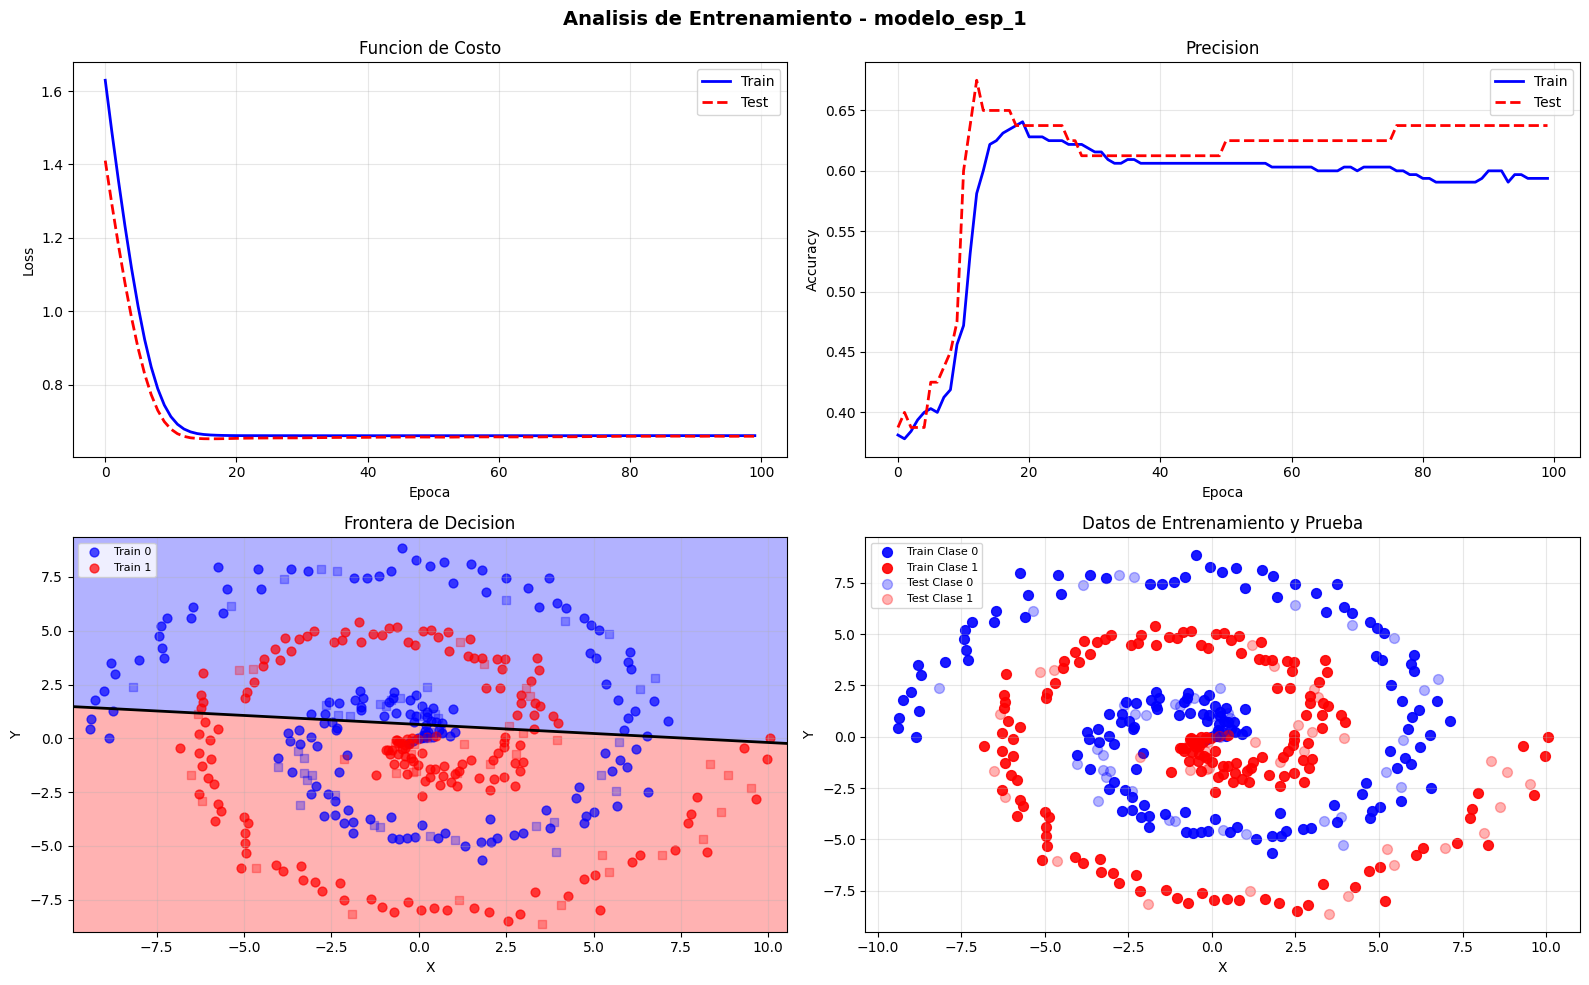

In [19]:
visualizar_entrenamiento(modelo_esp_1, historial_esp_1, X_train_esp, y_train_esp, X_test_esp, y_test_esp, nombre='modelo_esp_1')

## Caso 3: Clasificacion Multiclase (3 clases)

Ahora un problema con 3 clases. Cambios importantes:
- La salida tiene **3 neuronas** (una por clase)
- Usamos **softmax** en lugar de sigmoid
- La funcion de perdida es **sparse_categorical_crossentropy**

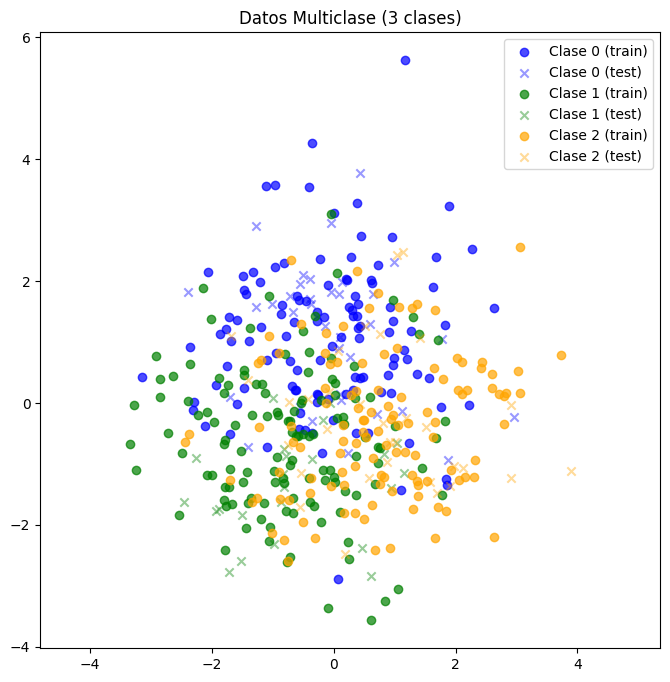

Train: 360 puntos | Test: 90 puntos


In [25]:
# Generar datos de 3 clases (clusters con superposicion y caos)
np.random.seed(42)
tf.random.set_seed(42)

n_puntos = 150  # puntos por clase

# Clase 0: cluster arriba (con dispersion)
x0 = np.random.randn(n_puntos) * 1.2
y0 = np.random.randn(n_puntos) * 1.2 + 1.0

# Clase 1: cluster abajo-izquierda (con dispersion)
x1 = np.random.randn(n_puntos) * 1.2 - 0.8
y1 = np.random.randn(n_puntos) * 1.2 - 0.6

# Clase 2: cluster abajo-derecha (con dispersion)
x2 = np.random.randn(n_puntos) * 1.2 + 0.8
y2 = np.random.randn(n_puntos) * 1.2 - 0.6

# Combinar datos
X_multi = np.vstack([
    np.column_stack([x0, y0]),
    np.column_stack([x1, y1]),
    np.column_stack([x2, y2])
])
y_multi = np.array([0] * n_puntos + [1] * n_puntos + [2] * n_puntos)

# Dividir en train/test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Visualizar
plt.figure(figsize=(8, 8))
colores = ['blue', 'green', 'orange']
for i, color in enumerate(colores):
    mask_train = y_train_m == i
    mask_test = y_test_m == i
    plt.scatter(X_train_m[mask_train, 0], X_train_m[mask_train, 1], c=color, label=f'Clase {i} (train)', alpha=0.7)
    plt.scatter(X_test_m[mask_test, 0], X_test_m[mask_test, 1], c=color, marker='x', label=f'Clase {i} (test)', alpha=0.4)

plt.title('Datos Multiclase (3 clases)')
plt.legend()
plt.axis('equal')
plt.show()

print(f"Train: {len(X_train_m)} puntos | Test: {len(X_test_m)} puntos")

In [26]:
import plotly.graph_objects as go

# Crear figura 3D interactiva
fig = go.Figure()

colores_3d = ['blue', 'green', 'orange']
nombres = ['Clase 0', 'Clase 1', 'Clase 2']

for i in range(3):
    mask = y_train_m == i
    fig.add_trace(go.Scatter3d(
        x=X_train_m[mask, 0],
        y=X_train_m[mask, 1],
        z=[i] * sum(mask),  # La clase como tercera dimension
        mode='markers',
        marker=dict(size=5, color=colores_3d[i], opacity=0.8),
        name=f'{nombres[i]} (train)'
    ))

fig.update_layout(
    title='Visualizacion 3D de los Datos Multiclase',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Clase'
    ),
    width=800,
    height=600
)

fig.show()

## Modelo Multiclase

In [27]:
modelo_multi = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(2,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')  # 3 neuronas para 3 clases
])

modelo_multi.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # para etiquetas enteras (0, 1, 2)
    metrics=['accuracy']
)

historial_multi = modelo_multi.fit(X_train_m, y_train_m, epochs=100, validation_data=(X_test_m, y_test_m), verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.1361 - loss: 1.3897 - val_accuracy: 0.2111 - val_loss: 1.1934
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3528 - loss: 1.0973 - val_accuracy: 0.5667 - val_loss: 0.9645
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5361 - loss: 0.9698 - val_accuracy: 0.6000 - val_loss: 0.8520
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5528 - loss: 0.9189 - val_accuracy: 0.6333 - val_loss: 0.8009
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5972 - loss: 0.8956 - val_accuracy: 0.6556 - val_loss: 0.7761
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6083 - loss: 0.8785 - val_accuracy: 0.6556 - val_loss: 0.7615
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6278 - loss: 0.8632 - val_accuracy: 0.6556 - val_loss: 0.7523
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6528 - loss: 0.8509 - val_accuracy: 0.


  RESULTADOS: modelo_multi

Entrenamiento -> Loss: 0.8248, Accuracy: 65.28%
Validacion    -> Loss: 0.7468, Accuracy: 64.44%



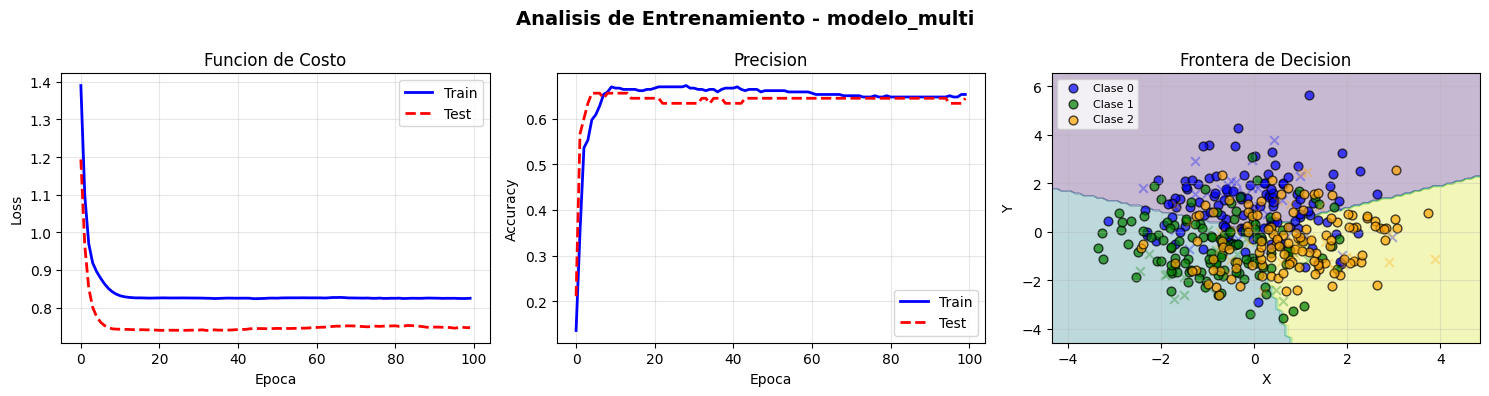

In [28]:
visualizar_multiclase(modelo_multi, historial_multi, X_train_m, y_train_m, X_test_m, y_test_m, nombre='modelo_multi')

---

# Bonus: Regresion con Redes Neuronales

Las redes neuronales no solo sirven para clasificacion. Tambien pueden **aproximar funciones matematicas**.

## Ejemplo: Fahrenheit a Celsius

La formula real es: **C = (F - 32) / 1.8**

Pero... que pasa si una red neuronal "aprende" esta relacion solo con datos?

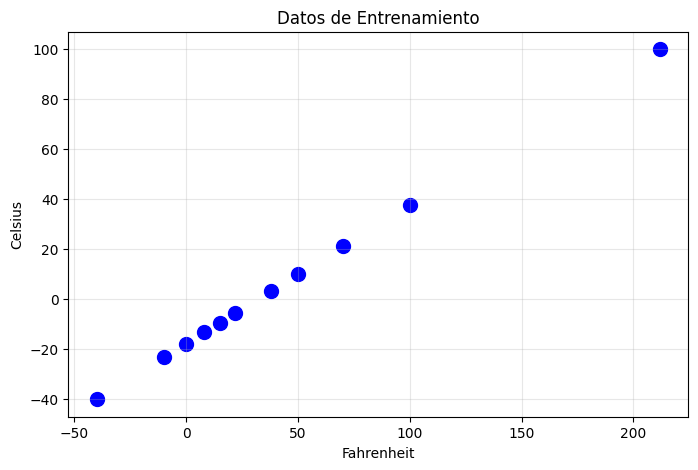

In [29]:
# Datos de entrenamiento: pares (Fahrenheit, Celsius)
fahrenheit = np.array([-40, -10, 0, 8, 15, 22, 38, 50, 70, 100, 212], dtype=float)
celsius = np.array([-40, -23.3, -17.8, -13.3, -9.4, -5.6, 3.3, 10, 21.1, 37.8, 100], dtype=float)

plt.figure(figsize=(8, 5))
plt.scatter(fahrenheit, celsius, s=100, c='blue')
plt.xlabel('Fahrenheit')
plt.ylabel('Celsius')
plt.title('Datos de Entrenamiento')
plt.grid(True, alpha=0.3)
plt.show()

## Modelo de Regresion

Usamos **una sola neurona** sin funcion de activacion. La red aprendera los pesos `w` y `b` para que:

**prediccion = w * fahrenheit + b**

In [30]:
# Modelo: una sola neurona (regresion lineal)
modelo_regresion = keras.Sequential([
    keras.layers.Dense(1, input_shape=(1,))  # Sin activacion = lineal
])

modelo_regresion.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss='mse'  # Error cuadratico medio
)

# Entrenar
historial_reg = modelo_regresion.fit(fahrenheit, celsius, epochs=500, verbose=0)

print("Entrenamiento completado!")

Entrenamiento completado!


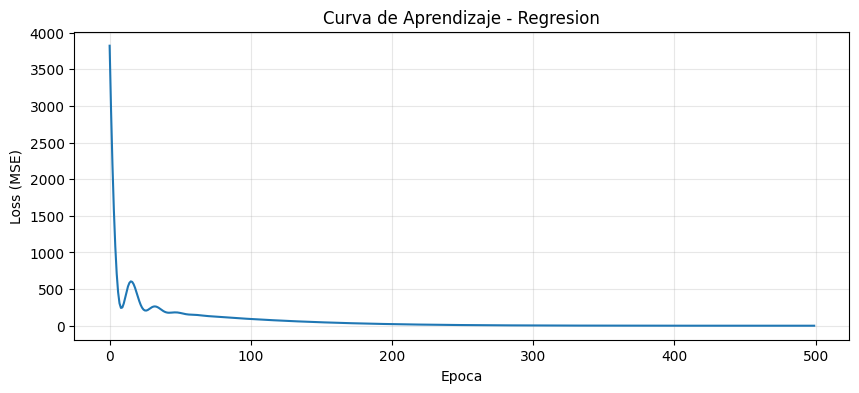

In [31]:
# Curva de perdida
plt.figure(figsize=(10, 4))
plt.plot(historial_reg.history['loss'])
plt.xlabel('Epoca')
plt.ylabel('Loss (MSE)')
plt.title('Curva de Aprendizaje - Regresion')
plt.grid(True, alpha=0.3)
plt.show()

## Los Pesos Aprendidos

Veamos que aprendio la red neuronal:

In [32]:
# Extraer pesos aprendidos
w_aprendido = modelo_regresion.layers[0].get_weights()[0][0][0]
b_aprendido = modelo_regresion.layers[0].get_weights()[1][0]

# Valores reales de la formula C = (F - 32) / 1.8
w_real = 1 / 1.8  # = 5/9 ≈ 0.5556
b_real = -32 / 1.8  # ≈ -17.78

print("=" * 50)
print("COMPARACION: Red Neuronal vs Formula Real")
print("=" * 50)
print(f"\nFormula real: C = (F - 32) / 1.8")
print(f"Equivalente a: C = {w_real:.4f} * F + ({b_real:.4f})")
print(f"\nRed neuronal aprendio: C = {w_aprendido:.4f} * F + ({b_aprendido:.4f})")
print(f"\nDiferencia en w: {abs(w_aprendido - w_real):.6f}")
print(f"Diferencia en b: {abs(b_aprendido - b_real):.6f}")

COMPARACION: Red Neuronal vs Formula Real

Formula real: C = (F - 32) / 1.8
Equivalente a: C = 0.5556 * F + (-17.7778)

Red neuronal aprendio: C = 0.5542 * F + (-17.5897)

Diferencia en w: 0.001333
Diferencia en b: 0.188073


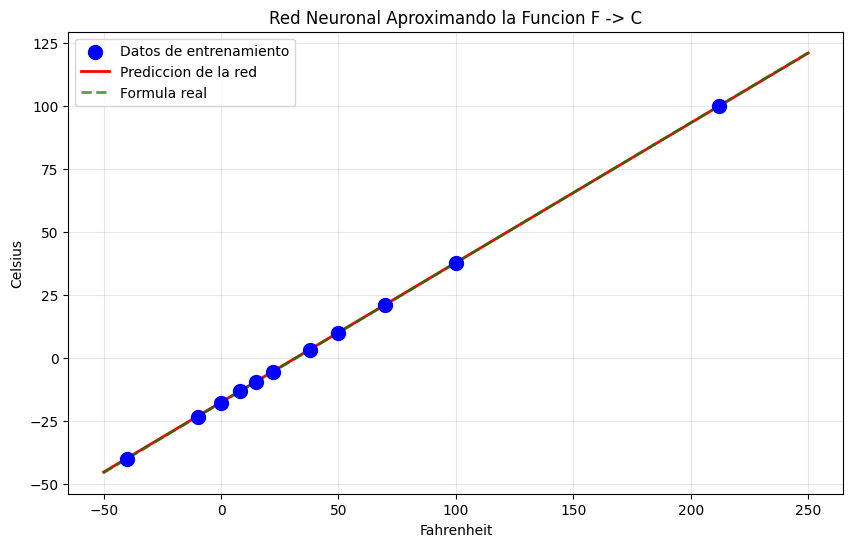


La red neuronal aprendio a aproximar la formula sin conocerla!


In [33]:
# Visualizar predicciones
f_range = np.linspace(-50, 250, 100)
predicciones = modelo_regresion.predict(f_range, verbose=0)
celsius_real = (f_range - 32) / 1.8

plt.figure(figsize=(10, 6))
plt.scatter(fahrenheit, celsius, s=100, c='blue', label='Datos de entrenamiento', zorder=5)
plt.plot(f_range, predicciones, 'r-', linewidth=2, label='Prediccion de la red')
plt.plot(f_range, celsius_real, 'g--', linewidth=2, alpha=0.7, label='Formula real')
plt.xlabel('Fahrenheit')
plt.ylabel('Celsius')
plt.title('Red Neuronal Aproximando la Funcion F -> C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nLa red neuronal aprendio a aproximar la formula sin conocerla!")

## Conclusion

Este ejemplo demuestra el **Teorema de Aproximacion Universal**: una red neuronal puede aproximar cualquier funcion continua.

Con solo **una neurona** (2 parametros: w y b), la red aprendio la relacion lineal entre Fahrenheit y Celsius, descubriendo por si misma los coeficientes de la formula matematica.